QUESTION 1


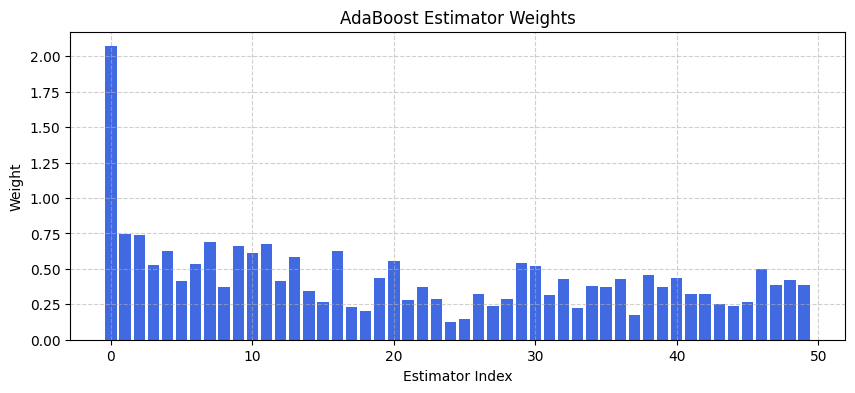

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification

# Generate dummy data
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Train AdaBoost
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X, y)

# Plot weights
plt.figure(figsize=(10, 4))
plt.bar(range(len(ada.estimator_weights_)), ada.estimator_weights_, color='royalblue')
plt.title('AdaBoost Estimator Weights')
plt.xlabel('Estimator Index')
plt.ylabel('Weight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 2. LightGBM Training and Timing
We will measure the training execution time of a LightGBM model.

In [ ]:
import time
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start_time = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"LightGBM training finished in {elapsed_time:.4f} seconds.")

LightGBM training finished in 0.1634 seconds.


In [ ]:
!pip install -q shap
import shap

explainer = shap.Explainer(lgb_model, X_train)
shap_values = explainer(X_test)

# Generate beeswarm plot
plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP Beeswarm Plot', fontsize=14)
plt.tight_layout()
plt.show()

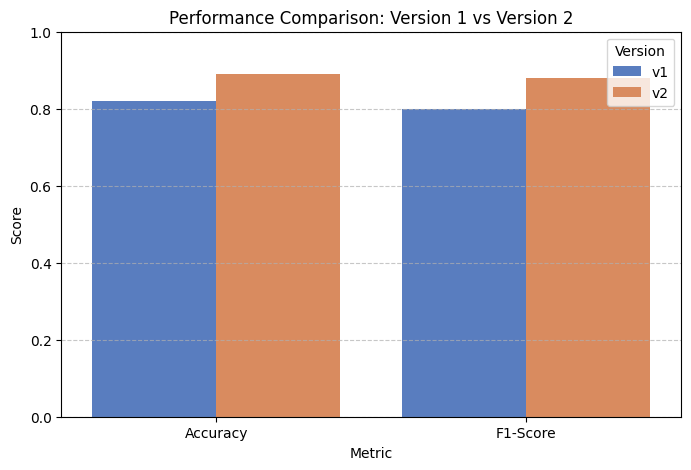

In [ ]:
import pandas as pd
import seaborn as sns

comparison_data = pd.DataFrame({
    'Version': ['v1', 'v2', 'v1', 'v2'],
    'Metric': ['Accuracy', 'Accuracy', 'F1-Score', 'F1-Score'],
    'Value': [0.82, 0.89, 0.80, 0.88]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Value', hue='Version', data=comparison_data, palette='muted')
plt.title('Performance Comparison: Version 1 vs Version 2')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

QUESTION 2

In [ ]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb

def boosting_benchmark(X_train, y_train, X_val, y_val):
    # Convert NumPy arrays to DataFrames to keep feature names consistent and avoid warnings
    if not isinstance(X_train, pd.DataFrame):
        cols = [f'feature_{i}' for i in range(X_train.shape[1])]
        X_train = pd.DataFrame(X_train, columns=cols)
        X_val = pd.DataFrame(X_val, columns=cols)

    # Initialize classifiers
    models = {
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'GradientBoosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1)
    }

    results = []

    # Train and evaluate each model
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        results.append({
            'Model': name,
            'val_accuracy': acc
        })

    # Create DataFrame and sort by validation accuracy descending
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='val_accuracy', ascending=False).reset_index(drop=True)
    return df_results

In [ ]:
# Demonstration of the benchmark function with the existing data splits
benchmark_df = boosting_benchmark(X_train, y_train, X_test, y_test)
display(benchmark_df)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,val_accuracy
0,XGBoost,0.96
1,GradientBoosting,0.95
2,LightGBM,0.95
3,AdaBoost,0.90
